# 8o Lab de PSD (notebook para preencher com os resultados)

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

### Número do Grupo : 5

In [ ]:
#
# Primeiro vamos importar as bibliotecas necessárias
#
import numpy as np
import matplotlib.pyplot as plt
import cv2

# **2.0 - Filtro de Gabor 2D (domínio frequência)**

No domínio da frequência, o filtro de Gabor 2D normalizado é definido por

$$\begin{aligned}
\Psi(u,v; f_o, \theta, \sigma_u, \sigma_v) = \exp \left(-\pi^2 \left( \frac{u'- f_o}{\sigma_u^2} + \frac{v'}{\sigma_v^2} \right) \right)
\end{aligned}$$

$$\begin{aligned}
u'&= u\cos\theta + v\sin\theta\\
v'&=-u\sin\theta + v\cos\theta\\
\end{aligned}$$

$f_o$ = frequência da onda senoidal

$\theta$ = ângulo de orientação do filtro

$\sigma_u$ e $\sigma_v$ = os desvios padrão da Gaussiana 2D na frequência

**OBS1**: Quando projetamos o filtro no domínio da frequência precisamos fazer com que $u$ e $v$ variem entre -0.5 e 0.5

**OBS2**: Para efeito de análise, observe que a seguinte relação acontece $\sigma_u = \frac{1}{2\pi \sigma_x}$ e $\sigma_v = \frac{1}{2\pi \sigma_y}$

## **2.1 - Implementação do filtro de Gabor 2D - domínio frequência**

In [ ]:
#
# Complex Gabor filter - frequency domain
#
def Gabor_freq_domain(M,N,f,theta,sigma_u,sigma_v):
    # -> INCLUA O SEU CÓDIGO AQUI !!
    u = np.linspace(-0.5, 0.5, M)
    v = np.linspace(-0.5, 0.5, N)
    U, V = np.meshgrid(u, v)

    d_u = U * np.cos(theta) + V * np.sin(theta)
    d_v = -U * np.sin(theta) + V * np.cos(theta)

    gab = np.exp(-np.pi**2 * (((d_u - f)**2/sigma_u**2) + d_v**2 / sigma_v**2))
    return gab

## **2.2 - Crie o filtro usando os parâmetros abaixo**

Crie um filtro Gabor 2D no domínio da frequência usando os parâmetros abaixo e plote as partes par e ímpar do filtro.

In [ ]:
sigma_x = 0.6
sigma_y = 1.2

sigma_u = 1/(2*np.pi*sigma_x)
sigma_v = 1/(2*np.pi*sigma_y)

M = 512
N = 512

fo = 0.1
theta = np.pi # 180º

# gab_freq = -> INCLUA O SEU CÓDIGO AQUI !!
gab_freq1 = Gabor_freq_domain(M,N,fo,theta,sigma_u,sigma_v)

[[2.16278326e-71 2.69246766e-71 3.34827717e-71 ... 2.73258540e-83
  1.96887182e-83 1.41708060e-83]
 [6.47043938e-71 8.05510616e-71 1.00171038e-70 ... 8.17512717e-83
  5.89031086e-83 4.23950669e-83]
 [1.92747250e-70 2.39952725e-70 2.98398470e-70 ... 2.43528018e-82
  1.75465861e-82 1.26290226e-82]
 ...
 [1.92747250e-70 2.39952725e-70 2.98398470e-70 ... 2.43528018e-82
  1.75465861e-82 1.26290226e-82]
 [6.47043938e-71 8.05510616e-71 1.00171038e-70 ... 8.17512717e-83
  5.89031086e-83 4.23950669e-83]
 [2.16278326e-71 2.69246766e-71 3.34827717e-71 ... 2.73258540e-83
  1.96887182e-83 1.41708060e-83]]


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

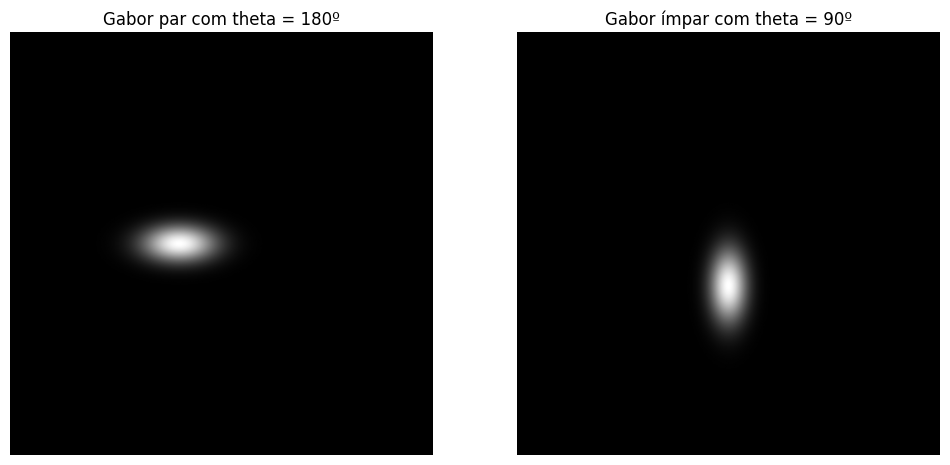

In [ ]:
plt.figure(figsize=(12,12))
plt.subplot(1, 2, 1)
# -> INCLUA O SEU CÓDIGO AQUI  - parte par do filtro !!
plt.title("Gabor par com theta = 180º")
plt.imshow(gab_freq1, cmap="gray")
print(gab_freq1)
plt.axis("off")

theta = np.pi / 2 # 90º
gab_freq2 = Gabor_freq_domain(M,N,fo,theta,sigma_u,sigma_v)

plt.subplot(1, 2, 2)
# -> INCLUA O SEU CÓDIGO AQUI  - parte ímpar do filtro !!
plt.title("Gabor ímpar com theta = 90º")
plt.imshow(gab_freq2, cmap="gray")
plt.axis("off")

## **2.2 - Filtragem no domínio frequência**

Utilizando o filtro Gabor 2D complexo implementado no domínio da frequência, realize a filtragem da imagem fornecida e **plote a magnitude do espectro de Fourier e a imagem filtrada**.

**DICA**: Para facilitar, crie o filtro com as mesmas dimensões da imagem.

Text(0.5, 1.0, 'Imagem sob análise')

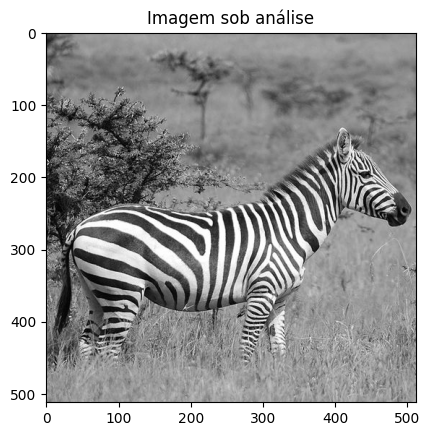

In [ ]:
#
# Mostre a imagem da magnitude do espectro de Fourier
#
# -> INCLUA O SEU CÓDIGO AQUI
imageRGB = cv2.imread('Zebra.jpg')
imageGRAY = cv2.cvtColor(imageRGB, cv2.COLOR_BGR2GRAY)

plt.imshow(imageGRAY, cmap="gray")
plt.title("Imagem sob análise")

In [ ]:
#
# Faça a filtragem da imagem no domínio da frequência
#
# -> INCLUA O SEU CÓDIGO AQUI
# filtro_gabor_shift = np.fft.ifftshift(filtro_gabor)

# filtro_gab_dft = np.fft.fft2(filtro_gabor_shift)
img_fft = np.fft.fft2(imageGRAY)
img_fft_shift = np.fft.fftshift(img_fft)

In [ ]:
#
# Retorne para o domínio da imagem e mostre a imagem filtrada n
#
# -> INCLUA O SEU CÓDIGO AQUI
theta = np.pi / 6 # 30º
gab_freq3 = Gabor_freq_domain(M,N,fo,theta,sigma_u,sigma_v)

img_filtrada_freq1 = img_fft_shift * gab_freq1
img_filtrada_freq1_shift = np.fft.ifftshift(img_filtrada_freq1)

img_filtrada_freq2 = img_fft_shift * gab_freq2
img_filtrada_freq2_shift = np.fft.ifftshift(img_filtrada_freq2)

img_filtrada_freq3 = img_fft_shift * gab_freq3
img_filtrada_freq3_shift = np.fft.ifftshift(img_filtrada_freq3)

img_filtrada1 = np.fft.ifft2(img_filtrada_freq1_shift)
img_filtrada2 = np.fft.ifft2(img_filtrada_freq2_shift)
img_filtrada3 = np.fft.ifft2(img_filtrada_freq3_shift)

Text(0.5, 1.0, 'Imagem filtrada com theta = 180º')

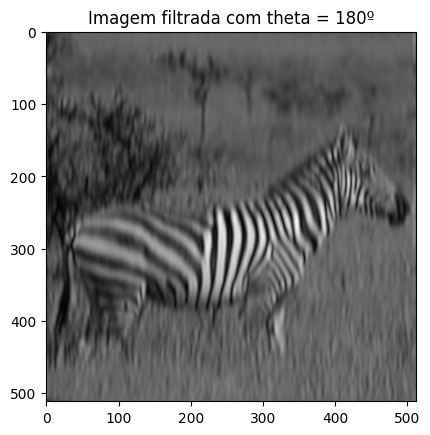

In [ ]:
plt.imshow(abs(img_filtrada1), cmap="gray")
plt.title("Imagem filtrada com theta = 180º")

Text(0.5, 1.0, 'Imagem filtrada com theta = 90º')

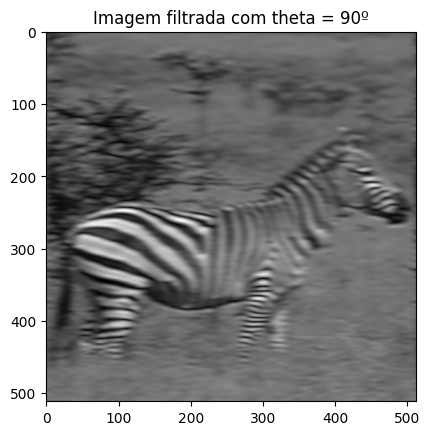

In [ ]:
plt.imshow(abs(img_filtrada2), cmap="gray")
plt.title("Imagem filtrada com theta = 90º")

Text(0.5, 1.0, 'Imagem filtrada com theta = 30º')

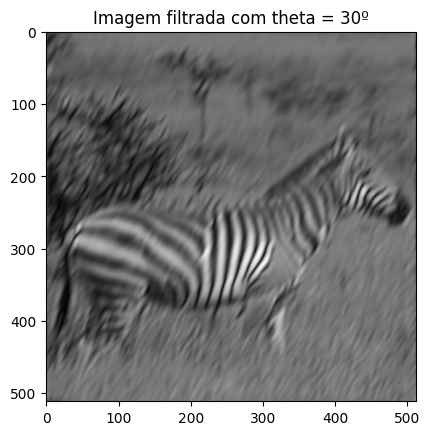

In [ ]:
plt.imshow(abs(img_filtrada3), cmap="gray")
plt.title("Imagem filtrada com theta = 30º")

## Criando um filtro isotrópico

Text(0.5, 1.0, 'Imagem filtrada com filtro isotrópico')

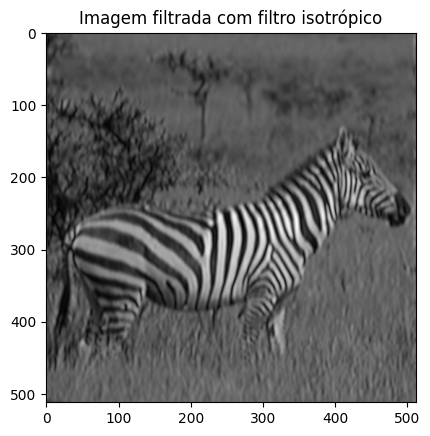

In [ ]:
# Filtro isotrópico -> sigma u = sigma v
sigma_x = 0.6
sigma_y = 0.6

sigma_u = 1/(2*np.pi*sigma_x)
sigma_v = 1/(2*np.pi*sigma_y)

theta = np.pi

gab_freq_iso = Gabor_freq_domain(M,N,fo,theta,sigma_u,sigma_v)

img_filtrada_freq4 = img_fft_shift * gab_freq_iso
img_filtrada_freq4_shift = np.fft.ifftshift(img_filtrada_freq4)

img_filtrada4 = np.fft.ifft2(img_filtrada_freq4_shift)

plt.imshow(abs(img_filtrada4), cmap="gray")
plt.title("Imagem filtrada com filtro isotrópico")

# **That's it for now !!**